# Quality Prediction of Manufactured Wine Using Physicochemical Properties

## Manufacturing Analytics Project

**Domain:** Quality and Yield Prediction  
**Industry:** Food and Beverage Manufacturing – Wine Industry  
**Dataset:** Wine Quality Dataset – UCI Machine Learning Repository

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
df = pd.read_csv("/content/winequality-red.csv")

print("Dataset loaded successfully!")

Dataset loaded successfully!


In [6]:
df = pd.read_csv("/content/winequality-red.csv", sep=";")

In [4]:
df.head()

,"fixed acidity;""volatile acidity"";""citric acid"";""residual sugar"";""chlorides"";""free sulfur dioxide"";""total sulfur dioxide"";""density"";""pH"";""sulphates"";""alcohol"";""quality"""
0,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5
1,7.8;0.88;0;2.6;0.098;25;67;0.9968;3.2;0.68;9.8;5
2,7.8;0.76;0.04;2.3;0.092;15;54;0.997;3.26;0.65;...
3,11.2;0.28;0.56;1.9;0.075;17;60;0.998;3.16;0.58...
4,7.4;0.7;0;1.9;0.076;11;34;0.9978;3.51;0.56;9.4;5


## Dataset Overview

In [7]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 1599
Number of columns: 12


In [8]:
print(df.columns.tolist())

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']


In [9]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [10]:
df.shape

(1599, 12)

In [11]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [13]:
df.isnull().sum()

,0
fixed acidity,0
volatile acidity,0
citric acid,0
residual sugar,0
chlorides,0
free sulfur dioxide,0
total sulfur dioxide,0
density,0
pH,0
sulphates,0


In [14]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 240


In [15]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## Data Cleaning

The dataset contains no missing values. However, 240 duplicate records were identified. Duplicate records are removed to avoid repeated observations influencing the machine learning models.

In [16]:
print("Rows before removing duplicates:", df.shape[0])

df = df.drop_duplicates()

print("Rows after removing duplicates:", df.shape[0])

Rows before removing duplicates: 1599
Rows after removing duplicates: 1359


In [17]:
print("Remaining duplicate rows:", df.duplicated().sum())

Remaining duplicate rows: 0


In [18]:
print("Dataset shape after cleaning:", df.shape)

Dataset shape after cleaning: (1359, 12)


## 5. Exploratory Data Analysis

### 5.1 Distribution of Wine Quality

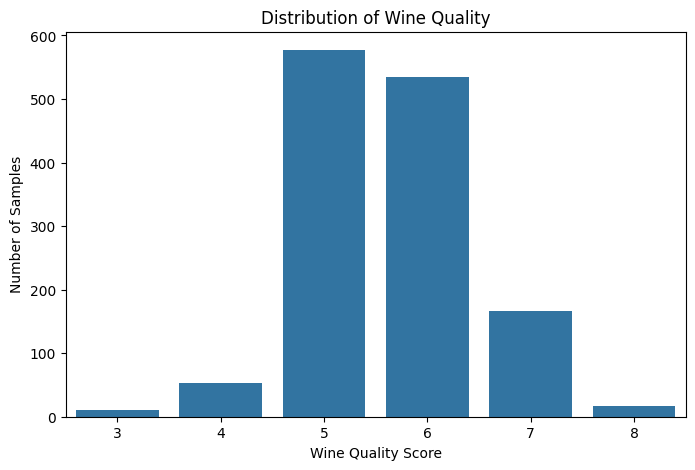

In [19]:
plt.figure(figsize=(8,5))

sns.countplot(data=df, x="quality")

plt.title("Distribution of Wine Quality")
plt.xlabel("Wine Quality Score")
plt.ylabel("Number of Samples")

plt.show()

In [20]:
df["quality"].value_counts().sort_index()

,count
quality,
3,10
4,53
5,577
6,535
7,167
8,17


### 5.2 Relationship Between Alcohol and Wine Quality

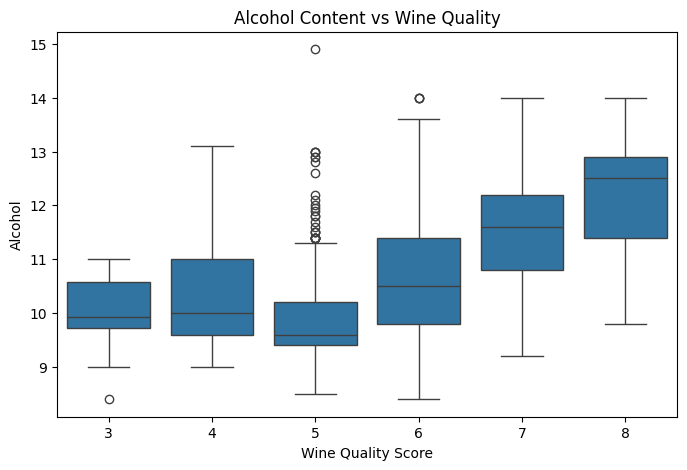

In [21]:
plt.figure(figsize=(8,5))

sns.boxplot(data=df, x="quality", y="alcohol")

plt.title("Alcohol Content vs Wine Quality")
plt.xlabel("Wine Quality Score")
plt.ylabel("Alcohol")

plt.show()

### 5.3 Correlation Between Physicochemical Properties

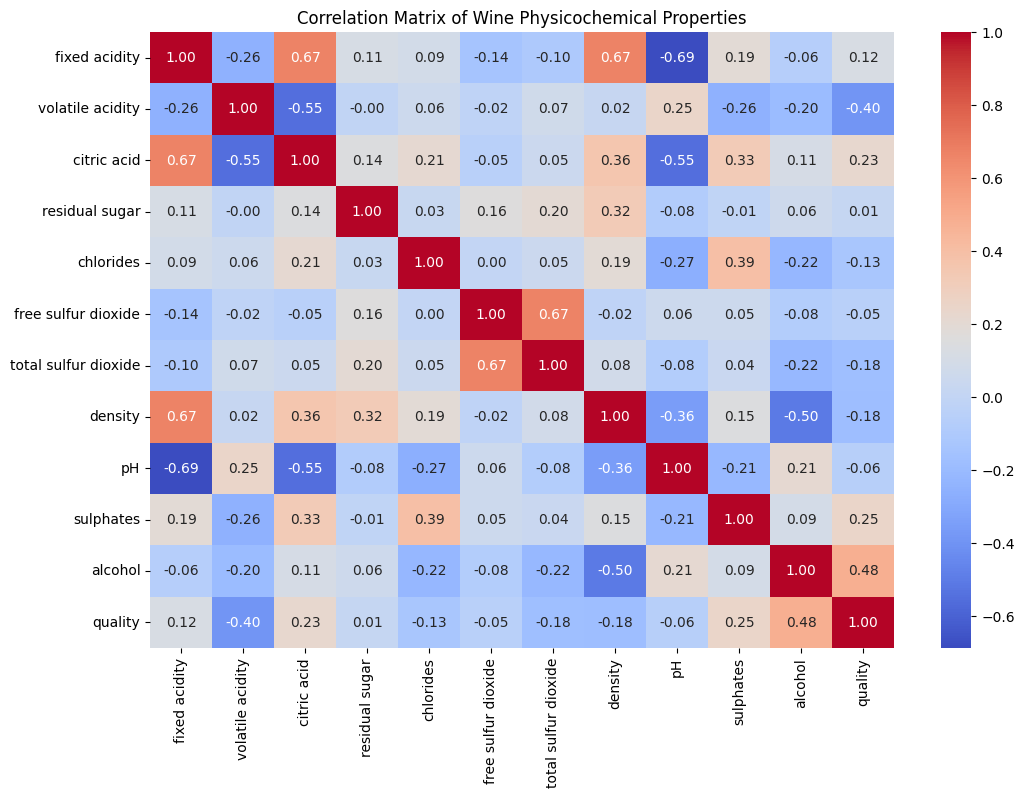

In [22]:
plt.figure(figsize=(12,8))

correlation = df.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix of Wine Physicochemical Properties")

plt.show()

In [23]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000,1359.000000
mean,8.310596,0.529478,0.272333,2.523400,0.088124,15.893304,46.825975,0.996709,3.309787,0.658705,10.432315,5.623252
std,1.736990,0.183031,0.195537,1.352314,0.049377,10.447270,33.408946,0.001869,0.155036,0.170667,1.082065,0.823578
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996700,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.430000,2.600000,0.091000,21.000000,63.000000,0.997820,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


## 6. Feature Engineering

### 6.1 Quality Class Creation

The original dataset contains wine quality scores ranging from 3 to 8. For manufacturing quality prediction, the quality scores are converted into two classes. Scores below 6 are considered lower quality, while scores of 6 or above are considered acceptable/good quality.

In [24]:
df["quality_class"] = df["quality"].apply(
    lambda x: 1 if x >= 6 else 0
)

df[["quality", "quality_class"]].head(10)

,quality,quality_class
0,5,0
1,5,0
2,5,0
3,6,1
5,5,0
6,5,0
7,7,1
8,7,1
9,5,0
10,5,0


In [25]:
df["quality_class"].value_counts()

,count
quality_class,
1,719
0,640


In [26]:
df["quality_class"].value_counts(normalize=True) * 100

,proportion
quality_class,
1,52.906549
0,47.093451


### 6.2 Feature and Target Separation

In [27]:
X = df.drop(columns=["quality", "quality_class"])
y = df["quality_class"]

print("Number of input features:", X.shape[1])
print("Target classes:", y.unique())

Number of input features: 11
Target classes: [0 1]


### 6.3 Train-Test Split

In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 1087
Testing samples: 272


## 7. Machine Learning Model Development

### 7.1 Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to make a more reliable classification. In this project, it is used to predict whether a wine sample belongs to the low-quality or good-quality class based on its physicochemical properties.

In [29]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [30]:
y_pred_rf = rf_model.predict(X_test)

print("Predictions generated successfully!")

Predictions generated successfully!


### 7.2 Random Forest Model Evaluation

In [31]:
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)

print("Random Forest Performance")
print("-------------------------")
print("Accuracy :", round(rf_accuracy, 4))
print("Precision:", round(rf_precision, 4))
print("Recall   :", round(rf_recall, 4))
print("F1 Score :", round(rf_f1, 4))

Random Forest Performance
-------------------------
Accuracy : 0.7574
Precision: 0.7868
Recall   : 0.7431
F1 Score : 0.7643


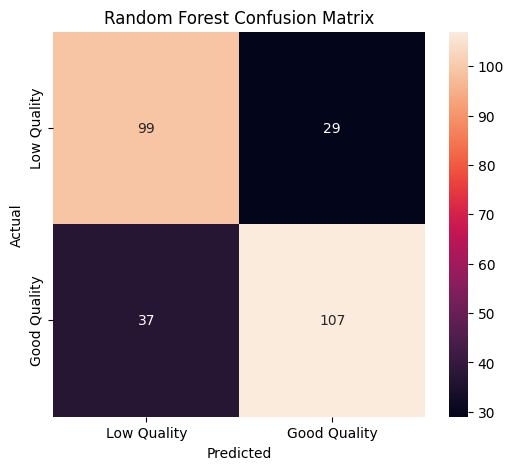

In [32]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=["Low Quality", "Good Quality"],
    yticklabels=["Low Quality", "Good Quality"]
)

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

### 7.3 XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is an ensemble machine learning algorithm that builds decision trees sequentially, where each new tree attempts to correct errors made by previous trees. In this project, XGBoost is used to predict whether a wine sample belongs to the low-quality or good-quality class.

In [33]:
xgb_model = XGBClassifier(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train)

print("XGBoost model trained successfully!")

XGBoost model trained successfully!


In [34]:
y_pred_xgb = xgb_model.predict(X_test)

print("XGBoost predictions generated successfully!")

XGBoost predictions generated successfully!


In [35]:
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)

print("XGBoost Performance")
print("-------------------")
print("Accuracy :", round(xgb_accuracy, 4))
print("Precision:", round(xgb_precision, 4))
print("Recall   :", round(xgb_recall, 4))
print("F1 Score :", round(xgb_f1, 4))

XGBoost Performance
-------------------
Accuracy : 0.7463
Precision: 0.7698
Recall   : 0.7431
F1 Score : 0.7562


## 8. Model Comparison

Random Forest and XGBoost were trained using the same training and testing datasets. Their performance was compared using accuracy, precision, recall, and F1-score.

In [36]:
results = pd.DataFrame({
    "Model": ["Random Forest", "XGBoost"],
    "Accuracy": [rf_accuracy, xgb_accuracy],
    "Precision": [rf_precision, xgb_precision],
    "Recall": [rf_recall, xgb_recall],
    "F1 Score": [rf_f1, xgb_f1]
})

results

,Model,Accuracy,Precision,Recall,F1 Score
0,Random Forest,0.757353,0.786765,0.743056,0.764286
1,XGBoost,0.746324,0.769784,0.743056,0.756184


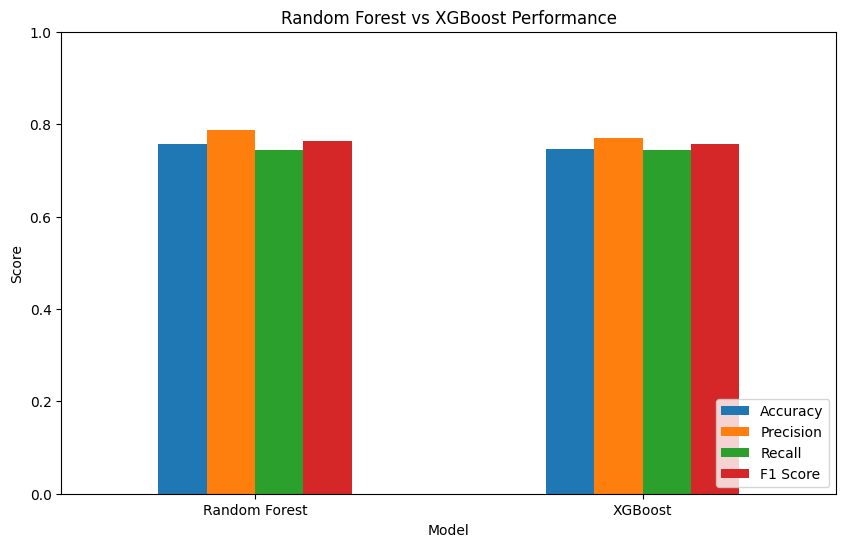

In [37]:
results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Random Forest vs XGBoost Performance")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=0)

plt.legend(loc="lower right")
plt.show()

## 9. Feature Importance

Feature importance is used to identify which physicochemical properties contribute most to the prediction of wine quality. This helps interpret the machine learning model and provides useful information for manufacturing quality control.

In [38]:
feature_importance = pd.Series(
    rf_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

feature_importance

,0
alcohol,0.209103
sulphates,0.123334
volatile acidity,0.108308
total sulfur dioxide,0.093918
density,0.082422
chlorides,0.073826
fixed acidity,0.066689
pH,0.066018
citric acid,0.061224
free sulfur dioxide,0.058850


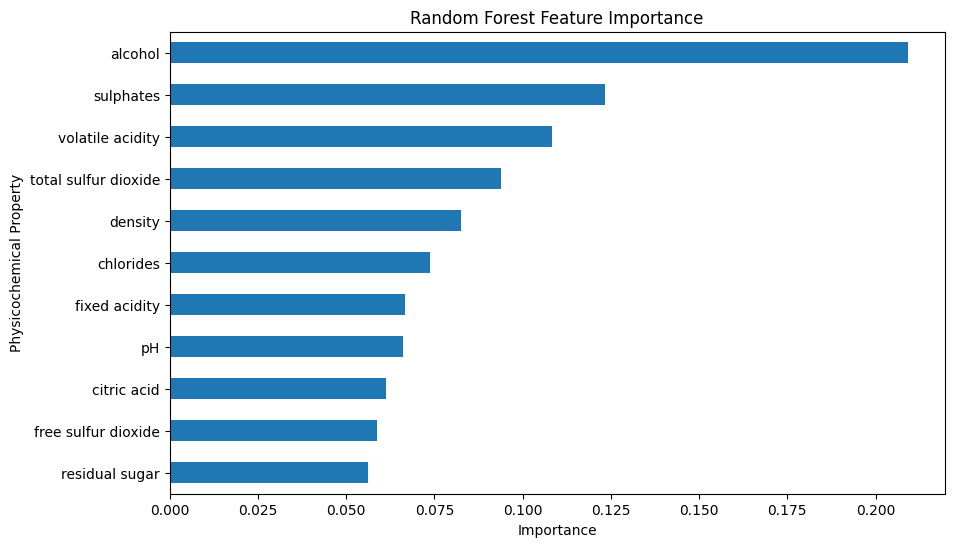

In [40]:
plt.figure(figsize=(10, 6))

feature_importance.sort_values().plot(kind="barh")

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Physicochemical Property")

plt.show()

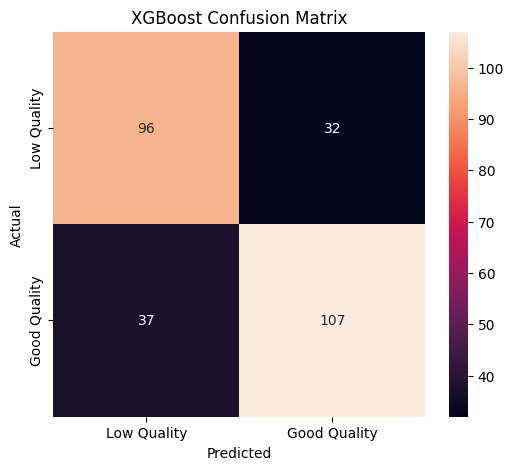

In [41]:
cm_xgb = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_xgb,
    annot=True,
    fmt="d",
    xticklabels=["Low Quality", "Good Quality"],
    yticklabels=["Low Quality", "Good Quality"]
)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

## 10. Final Wine Quality Prediction

The trained Random Forest model is used to predict the quality class of a new wine sample based on its 11 physicochemical properties.

In [42]:
def predict_wine_quality(
    fixed_acidity,
    volatile_acidity,
    citric_acid,
    residual_sugar,
    chlorides,
    free_sulfur_dioxide,
    total_sulfur_dioxide,
    density,
    pH,
    sulphates,
    alcohol
):

    new_sample = pd.DataFrame([[
        fixed_acidity,
        volatile_acidity,
        citric_acid,
        residual_sugar,
        chlorides,
        free_sulfur_dioxide,
        total_sulfur_dioxide,
        density,
        pH,
        sulphates,
        alcohol
    ]], columns=X.columns)

    prediction = rf_model.predict(new_sample)[0]

    if prediction == 1:
        return "Good Quality"
    else:
        return "Low Quality"

In [43]:
prediction = predict_wine_quality(
    fixed_acidity=7.5,
    volatile_acidity=0.50,
    citric_acid=0.30,
    residual_sugar=2.0,
    chlorides=0.07,
    free_sulfur_dioxide=20,
    total_sulfur_dioxide=50,
    density=0.996,
    pH=3.3,
    sulphates=0.70,
    alcohol=10.5
)

print("Predicted Wine Quality:", prediction)

Predicted Wine Quality: Good Quality


## 11. Final Model Selection

Random Forest and XGBoost were evaluated using accuracy, precision, recall, and F1-score. Based on the evaluation results, Random Forest achieved better overall performance than XGBoost. Therefore, Random Forest was selected as the final model for wine quality classification.

In [44]:
best_model = rf_model

print("Selected Final Model: Random Forest")
print("Accuracy:", round(rf_accuracy * 100, 2), "%")
print("F1 Score:", round(rf_f1 * 100, 2), "%")

Selected Final Model: Random Forest
Accuracy: 75.74 %
F1 Score: 76.43 %


## 12. Manufacturing Interpretation

The developed system can support wine manufacturing quality control by predicting whether a wine sample is likely to meet the defined quality level based on its physicochemical properties. The feature importance analysis identified alcohol, sulphates, volatile acidity, total sulfur dioxide, and density as the most influential parameters for the Random Forest model. Monitoring these parameters can help manufacturers identify potentially lower-quality batches and support timely quality-control decisions.

## 13. Conclusion

This project developed a machine learning-based wine quality prediction system using physicochemical properties from the UCI Wine Quality dataset. After data profiling and cleaning, 1,359 unique samples were used for model development. Random Forest and XGBoost were trained and compared. Random Forest achieved the best overall performance with an accuracy of 75.74% and an F1-score of 76.43%. The model can classify wine samples into low-quality and good-quality categories and identify important physicochemical parameters that contribute to the prediction. This approach can support data-driven quality monitoring in wine manufacturing.